# General notebook

In [33]:
using Revise
Revise.retry() # Just in case if only Revise is not sufficient. 
include("lattice_protein.jl")

Imports done, importing hamiltonian path
hamiltonian path imported, importing metropolis
metropolis imported, importing benchmark
benchmark imported, importing visualization
visualization imported, importing tree
tree imported, importing lattice_protein


## Hamiltonian paths

In [2]:
println("We find $(length(PATHS)) unique paths.")
println(first(PATHS))

We find 103346 unique paths.
Int8[1, 2, 3, 6, 5, 4, 7, 8, 9, 18, 17, 16, 13, 14, 15, 12, 11, 10, 19, 20, 21, 24, 23, 22, 25, 26, 27]


Contact map for the first path:
Path visualization for the 75005:


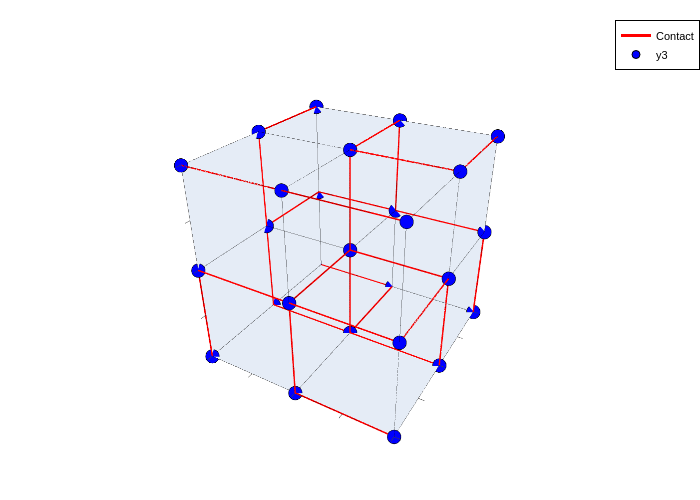

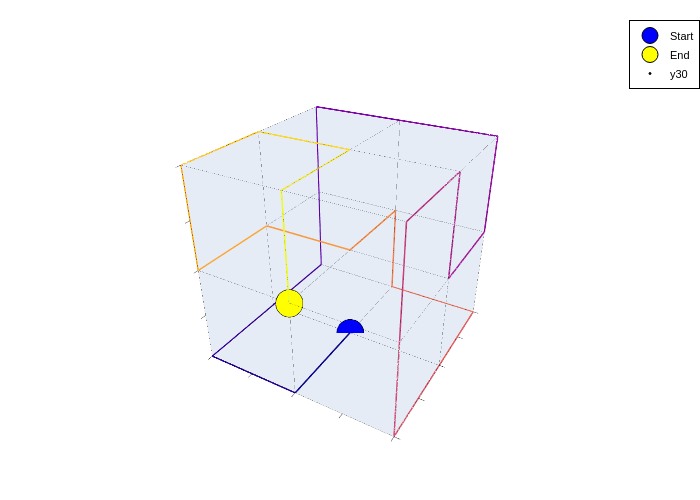

In [3]:
println("Contact map for the first path:")
liste_contact = contact_map(PATHS[75005])
display(plot_cube_ctc_map(x, y, z, lx, ly, lz, liste_contact))

println("Path visualization for the 75005:")
display(plot_cube_path(x, y, z, lx, ly, lz, PATHS[75005]))

## Metropolis general results

Attention : si on veut changer de matrice (MJ*5 ou MJ_1996) il faut restart le kernel et modifier la ligne const dans le ficher metropolis.jl. 

MJ*5

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:42


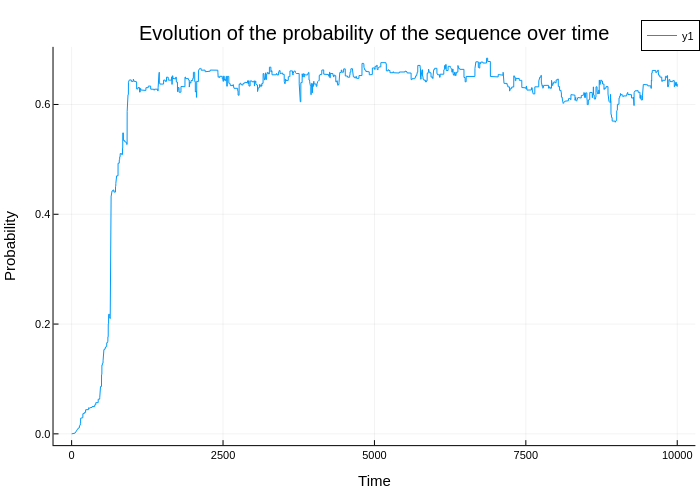

In [4]:
# with all the data
seq = generate_seq()
print(matrix_name)
target_number = 75005
all_ctc_maps = all_contact_maps(PATHS)
plot_probability(seq, target_number, all_ctc_maps, 10000)

MJ*5

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:04


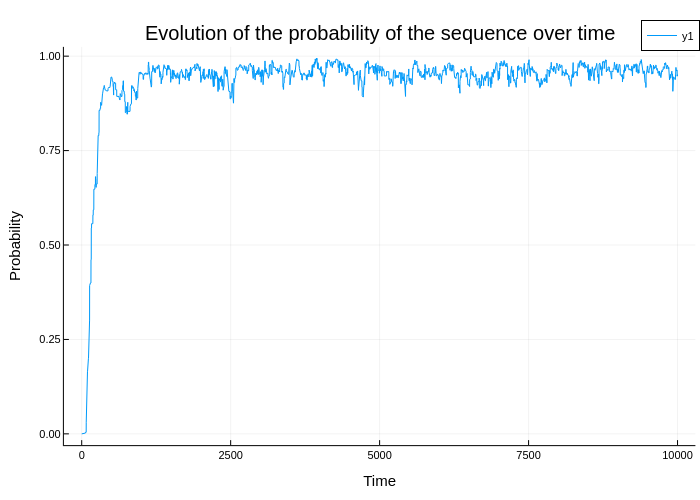

In [5]:
# with few data
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
print(matrix_name)

all_ctc_maps = all_contact_maps(paths_reduced)
plot_probability(seq, target_number, all_ctc_maps, 10000)

Testing beta = 10


algo (β=10) 100%|████████████████████████████████████████| Time: 0:00:01


Testing beta = 50


algo (β=50) 100%|████████████████████████████████████████| Time: 0:00:01


Testing beta = 100


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:01


Testing beta = 1000


algo (β=1000) 100%|██████████████████████████████████████| Time: 0:00:01


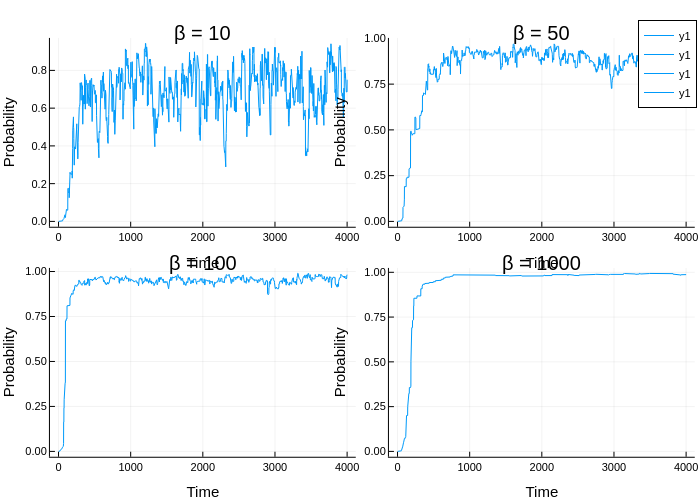

Dict{Float64, Tuple{Vector{Int64}, Vector{Float64}}} with 4 entries:
  50.0   => ([11, 16, 12, 9, 14, 6, 4, 16, 15, 5  …  18, 6, 7, 5, 16, 6, 16, 18…
  10.0   => ([3, 18, 14, 16, 15, 6, 18, 17, 16, 14  …  18, 14, 2, 13, 5, 17, 1,…
  1000.0 => ([1, 17, 18, 15, 16, 9, 18, 9, 18, 1  …  16, 1, 2, 2, 6, 17, 19, 5,…
  100.0  => ([9, 15, 10, 18, 19, 1, 15, 6, 18, 16  …  15, 18, 17, 17, 1, 18, 1,…

In [6]:
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)


benchmark_beta()

## Further observations

### Chain evolution

ici

Multi-init 100%|█████████████████████████████████████████| Time: 0:00:13


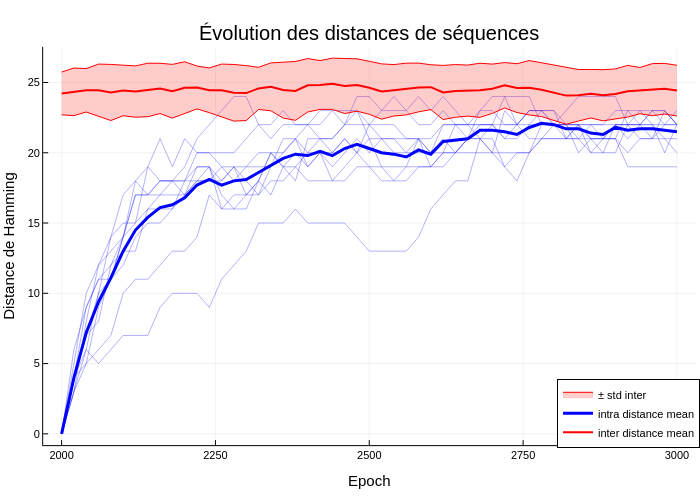

In [7]:
paths_reduced = reduce_data(PATHS, 10)
beta = 100.0

seq_over_time = multi_init_seq_over_time(target_number, all_ctc_maps, epochs=3000, beta=beta, threshold=2000, step=20, runs=10)
plot_distances_inter_intra(seq_over_time, beta=beta)

### All proba

In [8]:
final_seq, p_struct_time_t, p_final,_=algo_show_probability_distribution(seq, target_number, all_ctc_maps, 10000, 100)
show_sorted_indices(p_final)

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:04


structure 1234 : 0.9722381549231015
structure 1558 : 0.008001274086423028
structure 1233 : 0.005363414413954853
structure 1797 : 0.002180601573329434
structure 2332 : 0.0016982542128757203
structure 529 : 0.0016982542128757042
structure 5133 : 0.0013904129506255986
structure 5033 : 0.0013904129506255903
structure 5179 : 0.0008865664396983666
structure 7760 : 0.00046282826566258333
structure 1563 : 0.0004187843328961944
structure 493 : 0.0003604510157256015
structure 5193 : 0.000360451015725599
structure 4977 : 0.00036045101572559744
structure 557 : 0.00021862459236213948
structure 5084 : 0.0001540621463572087
structure 5082 : 0.00015406214635720755
structure 570 : 0.00014654844681671094
structure 1230 : 0.00012613541710784505
structure 5097 : 0.0001199837202246545


### Mutations on the cube

In [9]:
# Mutations en fonction de la position
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234

all_ctc_maps = all_contact_maps(paths_reduced)

beta = 100

_, _, saved_seq = algo(seq, target_number, all_ctc_maps, 10000, beta, 2000, 200)
println("On a sauvegardé $(length(saved_seq)) structures.")

n_mutations_per_position = amount_of_mutations(saved_seq)
n_mutations_per_position


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:04


On a sauvegardé 41 structures.


Dict{Int64, Int64} with 27 entries:
  5  => 30
  16 => 15
  20 => 28
  12 => 22
  24 => 16
  8  => 31
  17 => 25
  1  => 40
  19 => 27
  23 => 33
  22 => 14
  6  => 29
  11 => 23
  9  => 13
  14 => 16
  3  => 29
  7  => 14
  25 => 12
  13 => 28
  ⋮  => ⋮

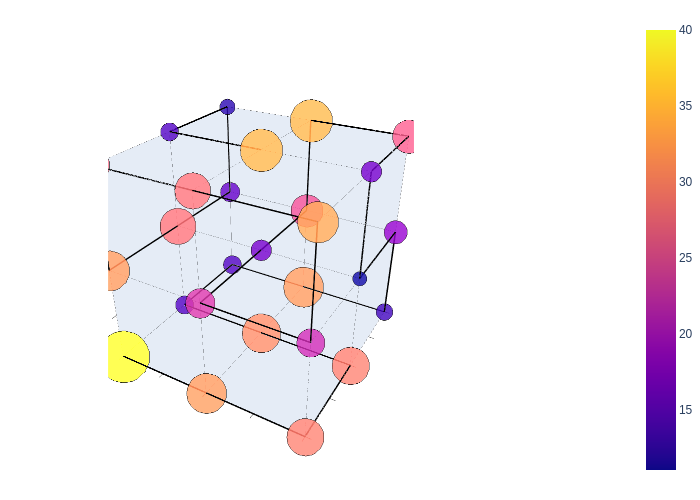

In [10]:
plot_cube_with_mutations_on_sphere(x, y, z, lx, ly, lz, PATHS[target_number], n_mutations_per_position)

In [11]:
beta = 100
target_number = 1234
epoch_start, epoch_stop, step = 2000, 10000, 200

paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
all_ctc_maps = all_contact_maps(paths_reduced)

_, _, saved_seq = algo(seq, target_number, all_ctc_maps, epoch_stop, beta, epoch_start, step)
println("On a sauvegardé $(length(saved_seq)) structures.")

plot_gif_cube_with_mutations(x, y, z, lx, ly, lz, PATHS[target_number], saved_seq)


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:04


On a sauvegardé 41 structures.
GIF sauvegardé : ../figures/mutations.gif


┌ Info: Saved animation to /home/gabriel/Documents/S2/Projet_BIM/pBIM/figures/mutations.gif
└ @ Plots /home/gabriel/.julia/packages/Plots/xC48f/src/animation.jl:156


## Tree generation

In [36]:
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)
beta = 100

root_seq,p_struct_time_t,_ = algo(seq, target_number, all_ctc_maps, 5000, beta, 10000, 200, true)
proba_final_root = p_struct_time_t[end]
println(proba_final_root)

newick, seq_dict = create_genealogy(root_seq, 50, 2, target_number, all_ctc_maps, beta=100 )

println(newick)

# Charger l'arbre dans TreeTools
tree = parse_newick_string(newick)

for node in nodes(tree)
    name = label(node)
    println("$name : " * join([aa_idx[acid] for acid in seq_dict[name]], " "))
end

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:02


0.9608978898285938
((N3:50,N4:50)N2:50,(N6:50,N7:50)N5:50)N1;
N3 : TRP ASP PHE CYS LYS ASP CYS GLU GLN ASN ILE LEU MET CYS PRO TRP ASN LYS ARG ARG THR CYS ASP TRP CYS ARG CYS
N4 : TRP ASN VAL CYS LYS GLU CYS GLU GLU LYS VAL LEU PRO THR ARG VAL ASN LYS ASN LYS ASP CYS GLU SER LEU ARG ARG
N5 : GLY LYS VAL CYS LYS GLY CYS ASP GLU GLU PHE PHE GLU PHE ARG PHE ASN LYS LYS ASP LYS PHE HIS LEU PHE ASP ILE
N7 : CYS GLY PHE CYS LYS CYS CYS ASP GLU GLU VAL ILE ILE CYS PRO TRP ASP LYS GLU ASP ASP CYS ASN LEU MET ARG PRO
N1 : ILE GLY PHE CYS LYS ASP CYS GLU TYR GLU LEU MET LEU ILE ARG VAL ASN LYS LYS ASN LYS MET ASP TRP PHE GLU LEU
N6 : LEU GLU CYS CYS LYS ASP CYS GLN GLU SER PHE VAL ILE HIS LYS MET ASP LYS GLU ASP ARG ILE ASP GLN PHE LYS ALA
N2 : PHE GLU PRO CYS LYS ASP CYS GLU GLN LYS PHE LEU VAL PRO ARG PHE ASN LYS ASN LYS THR CYS ASP TRP PHE THR ILE


In [39]:
N1= seq_dict["N1"]
N3 = seq_dict["N3"]
println(hamming_distance(N1,N3))

17


In [13]:
simple_print_distance_matrix(seq_dict)

      N3    N4    N5    N7    N1    N6    N2    
N3    0     18    18    20    16    21    17    
N4    18    0     17    18    18    17    13    
N5    18    17    0     17    18    18    15    
N7    20    18    17    0     19    18    20    
N1    16    18    18    19    0     19    16    
N6    21    17    18    18    19    0     19    
N2    17    13    15    20    16    19    0     


In [14]:
p = plot_distance_matrix(seq_dict)
savefig(p, "../figures/distance_matrix.svg")

"/home/gabriel/Documents/S2/Projet_BIM/pBIM/figures/distance_matrix.svg"

In [15]:
tree


                                        _____________________________________ N3
  _____________________________________|
 |                                     |_____________________________________ N4
_|
 |                                      _____________________________________ N6
 |_____________________________________|
                                       |_____________________________________ N7


In [37]:
result = fitch_reconstruction(tree, seq_dict)

for (name, seq) in sort(collect(result))
    println("$name : " * join([aa_idx[acid] for acid in seq], " "))
end

N1 : LEU ASP PHE CYS LYS ASP CYS GLN GLU GLU VAL LEU ILE CYS PRO TRP ASP LYS GLU ASP ASP CYS ASP LEU LEU ARG PRO
N2 : TRP ASP PHE CYS LYS ASP CYS GLU GLU ASN VAL LEU PRO CYS PRO TRP ASN LYS ARG ARG ASP CYS ASP TRP LEU ARG ARG
N3 : TRP ASP PHE CYS LYS ASP CYS GLU GLN ASN ILE LEU MET CYS PRO TRP ASN LYS ARG ARG THR CYS ASP TRP CYS ARG CYS
N4 : TRP ASN VAL CYS LYS GLU CYS GLU GLU LYS VAL LEU PRO THR ARG VAL ASN LYS ASN LYS ASP CYS GLU SER LEU ARG ARG
N5 : LEU GLU PHE CYS LYS ASP CYS GLN GLU GLU VAL ILE ILE CYS PRO TRP ASP LYS GLU ASP ASP CYS ASP LEU MET ARG PRO
N6 : LEU GLU CYS CYS LYS ASP CYS GLN GLU SER PHE VAL ILE HIS LYS MET ASP LYS GLU ASP ARG ILE ASP GLN PHE LYS ALA
N7 : CYS GLY PHE CYS LYS CYS CYS ASP GLU GLU VAL ILE ILE CYS PRO TRP ASP LYS GLU ASP ASP CYS ASN LEU MET ARG PRO


In [17]:
root_name_reconstructed, root_seq_reconstructed = first(sort(collect(result)))

"N1" => [8, 13, 13, 2, 18, 2, 5, 13, 15, 5  …  18, 13, 16, 18, 1, 12, 2, 1, 16, 4]

In [18]:
reconstruction_error_hamming(result, seq_dict)

7.142857142857143

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:02


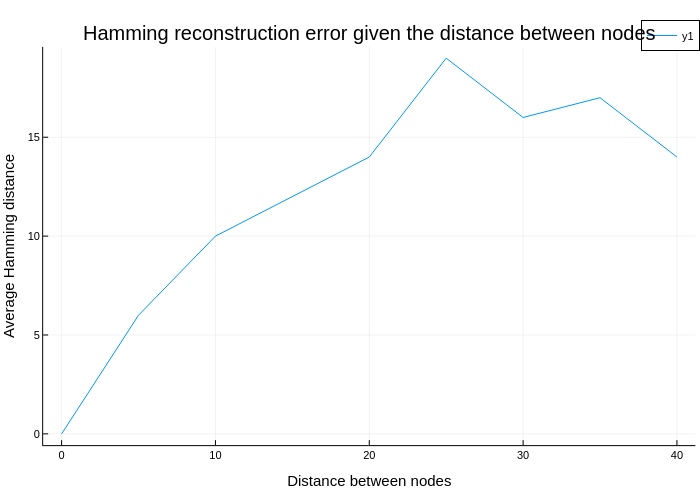

In [42]:
distance_btw_nodes = 0:5:40
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)
number_of_nodes = 4

root_seq,_,_ = algo(seq, target_number, all_ctc_maps, 5000, 100, 10000, 200, true)

plot_reconstruction_error_hamming(root_seq, distance_btw_nodes, number_of_nodes, target_number, all_ctc_maps, beta=100)

In [24]:
reconstruction_error_prob_folding(result, seq_dict, all_ctc_maps, target_number)

-0.031667639664250645

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:02


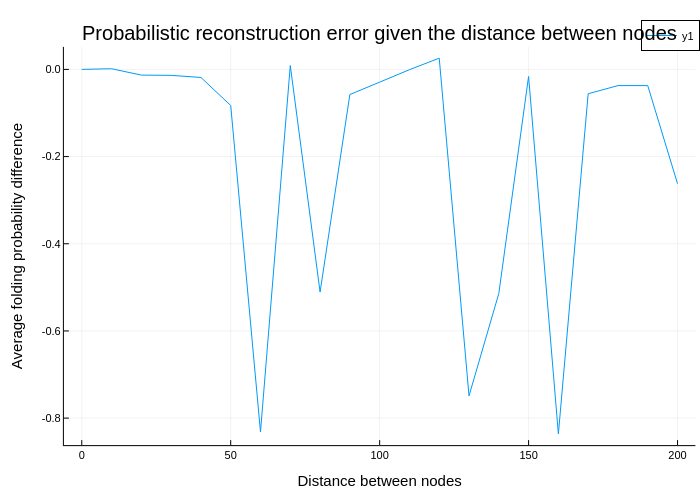

In [35]:
distance_btw_nodes = 0:10:200
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)
number_of_nodes = 2

root_seq,_,_ = algo(seq, target_number, all_ctc_maps, 5000, 100, 10000, 200, true)

plot_reconstruction_error_proba(root_seq, distance_btw_nodes, number_of_nodes, target_number, all_ctc_maps, beta=100)

In [ ]:
#IQ-TREE
#Voir consensus feuilles
#Faire moyenne plusieurs itérations